# Интерпретация

#  Задание 6. 2 балла. LIME.
Постройте интерпретацию признаков для нескольких примеров с помощью LIME. Можете использовать 
Оцените устойчивость реализации. Как влияет на коэффициенты количество сгенерированных точек? А выбор признаков (lasso/добавление фичей по порядку). А выбор ядра?

(*) Вы получите на 2 балла больше, если используете свою реализацию из задания семинарского ноутбука. В таком случае не забудьте добавить тесты для своей реализации. 



## Подготовка данных и моделей

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.inspection import PartialDependenceDisplay, permutation_importance
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error

warnings.filterwarnings("ignore")
%config InlineBackend.figure_format = 'retina'

# Загрузка данных
data = pd.read_csv("data_unreg.csv")

# Признаки
num_features = [
    "location_marketplace_cnt",
    "location_amenity_pharmacy_w_mean_distance",
    "location_public_transport_stop_position_cnt",
    "location_college_cnt",
    "location_railway_cnt",
    "location_logs_count_std",
    "location_leisure_cnt",
    "location_shop_product_w_mean_distance",
    "location_public_transport_platform_w_mean_distance",
    "location_leisure_w_mean_distance",
    "location_flash_mean_mean",
    "location_market_cnt",
    "location_barrier_w_mean_distance",
]
cat_features = [
    "region_name_cat", "class_cat", "district_cat",
    "hc_name_cat", "developer_cat", "corpus_cat", "stage_cat",
]

X = data.drop(columns=["price_target"])
y = data["price_target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# Pipeline-модели
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  MinMaxScaler()),
])
cat_pipeline = Pipeline([
    ("imputer",  SimpleImputer(strategy="most_frequent")),
    ("encoder",  OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])
preprocessor = ColumnTransformer([
    ("num", num_pipeline, num_features),
    ("cat", cat_pipeline, cat_features),
])

lin_model = Pipeline([("preprocessor", preprocessor),
                       ("model", LinearRegression())])
gb_model  = Pipeline([("preprocessor", preprocessor),
                       ("model", GradientBoostingRegressor(max_depth=5, random_state=42))])

lin_model.fit(X_train, y_train)
gb_model.fit(X_train, y_train)

print("Модели обучены")
print(f"  Train: {X_train.shape}  |  Test: {X_test.shape}")


Модели обучены
  Train: (23924, 82)  |  Test: (5981, 82)


## Как работает своя реализация (далее MyLIME)

### Алгоритм шаг за шагом

**1. Генерация соседей**
Сэмплируем n_samples случайных точек вокруг объекта x*.
В нашей реализации - из нормального распределения N(μ, σ) по обучающей выборке.

**2. Получение предсказаний чёрного ящика**
Для каждого соседа спрашиваем у модели f предсказание. Модель при этом - полный
pipeline с MinMaxScaler и всеми признаками.

**3. Взвешивание через ядро**
Чем ближе сосед к x*, тем больше его вес. Расстояние считается в нормализованном
пространстве (делим на σ признаков).

Два ядра в нашей реализации:
- Gaussian: w = exp(−d²) - мягкое убывание, все соседи имеют ненулевой вес
- Epanechnikov: w = 0.75(1−d²) при d≤1, иначе 0 - жёсткое обнуление дальних точек

**4. Обучение взвешенной линейной модели**
Ridge-регрессия с sample_weight=веса. Коэффициенты обученной модели - это и есть
объяснение: положительный коэффициент = признак повышает предсказание для данного
объекта, отрицательный = понижает.

**5. Отбор признаков**
- lasso_path: сначала обучаем Lasso, берём только ненулевые коэффициенты: контрастное объяснение
- none: берём первые num_features признаков без отбора

---

### Ключевые параметры и их влияние

**kernel_width (σ ядра)**
Определяет радиус доверия вокруг объекта.
- Маленький: объяснение очень локальное, но нестабильное (мало соседей с ненулевым весом)
- Большой: объяснение усредняется по широкой окрестности, приближается к глобальному

**n_samples**
Число соседей для аппроксимации. Больше: стабильнее коэффициенты, дольше работает.
На практике от 1000 коэффициенты достаточно стабильны.

**feature_selection**
lasso_path даёт более интерпретируемый результат.
none показывает вклад всех признаков, но при корреляциях - нестабильно.

---

### Ограничения MyLIME vs библиотечного LIME

| | Наша реализация | lime.lime_tabular |
|---|---|---|
| Генерация соседей | N(μ, σ) глобально | N(μ, σ) + дискретизация |
| Расстояние | L2 в норм. пространстве | L2 в дискретизированном |
| Ядро | Gaussian / Epanechnikov | Только Gaussian |
| Отбор признаков | Lasso / none | Lasso / forward selection |
| Стабильность | Ниже из-за глобального сэмплинга | Выше |

## Реализация

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler


class MyLimeExplainer:

    def __init__(self, training_data: np.ndarray, feature_names: list,
                 kernel_width: float = 0.75, kernel: str = "gaussian",
                 random_state: int = 42):
        """
        Parameters
        ----------
        training_data : np.ndarray, shape (n, d)
            Обучающая выборка - используется для оценки mean/std при генерации соседей.
        feature_names : list of str
        kernel_width : float
            Ширина ядра (σ).
        kernel : str
            'gaussian' или 'epanechnikov'
        random_state : int
        """
        self.training_data = training_data
        self.feature_names = feature_names
        self.kernel_width = kernel_width
        self.kernel = kernel
        self.rng = np.random.RandomState(random_state)

        self.mu = training_data.mean(axis=0)
        self.sigma = training_data.std(axis=0) + 1e-8

    # Ядра
    def _apply_kernel(self, distances: np.ndarray) -> np.ndarray:
        d = distances / self.kernel_width
        if self.kernel == "gaussian":
            weights = np.exp(-(d ** 2))
        elif self.kernel == "epanechnikov":
            weights = np.where(d <= 1, 0.75 * (1 - d ** 2), 0.0)
        else:
            raise ValueError(f"Unknown kernel: {self.kernel}")
        if weights.sum() == 0:
            weights = np.ones_like(weights)
        return weights

    # Объяснение одного объекта
    def explain_instance(self, instance: np.ndarray, predict_fn,
                         num_features: int = 5, n_samples: int = 1000,
                         feature_selection: str = "lasso_path") -> dict:

        instance = np.array(instance, dtype=float)

        # 1. Генерация соседей
        neighbors = self.rng.randn(n_samples, len(instance)) * self.sigma + self.mu

        # 2. Предсказания чёрного ящика
        preds = predict_fn(neighbors)

        # 3. Расстояния и веса
        distances = np.linalg.norm(
            (neighbors - instance) / self.sigma, axis=1)
        weights = self._apply_kernel(distances)

        # 4. Отбор признаков
        if feature_selection == "lasso_path":
            selected = self._select_features_lasso(
                neighbors, preds, weights, num_features)
        else:
            selected = list(range(len(instance)))[:num_features]

        # 5. Взвешенная Ridge-регрессия на отобранных признаках
        X_sel = neighbors[:, selected]
        reg = Ridge(alpha=1.0, fit_intercept=True)
        reg.fit(X_sel, preds, sample_weight=weights)

        return {self.feature_names[i]: coef
                for i, coef in zip(selected, reg.coef_)}

    def _select_features_lasso(self, X, y, weights, k):
        from sklearn.linear_model import Lasso
        scaler = StandardScaler()
        X_sc = scaler.fit_transform(X)
        for alpha in [0.1, 0.05, 0.01, 0.001, 1e-5]:
            lasso = Lasso(alpha=alpha, max_iter=5000)
            lasso.fit(X_sc, y, sample_weight=weights)
            nonzero = np.where(lasso.coef_ != 0)[0]
            if len(nonzero) >= k:
                return list(nonzero[:k])
        # fallback: топ-k по |coef|
        return list(np.argsort(np.abs(lasso.coef_))[::-1][:k])

    def plot_explanation(self, explanation: dict, title: str = "LIME explanation"):
        names = list(explanation.keys())
        coefs = list(explanation.values())
        colors = ["steelblue" if c > 0 else "coral" for c in coefs]
        plt.figure(figsize=(8, max(3, len(names) * 0.5)))
        plt.barh(names, coefs, color=colors)
        plt.axvline(0, color="black", linewidth=0.8)
        plt.title(title)
        plt.xlabel("Coefficient")
        plt.gca().invert_yaxis()
        plt.tight_layout()
        plt.show()


## Тесты

In [3]:
# Тесты для MyLime
import numpy as np

# Вспомогательные данные
rng = np.random.RandomState(0)
X_dummy = rng.randn(200, 4)
feature_names_dummy = ["f0", "f1", "f2", "f3"]

# 1. Тест: explain_instance возвращает словарь нужного размера
def test_output_shape():
    explainer = MyLimeExplainer(X_dummy, feature_names_dummy, random_state=0)
    linear_fn = lambda X: X[:, 0] * 2 + X[:, 1] * (-1)  # простая линейная функция
    exp = explainer.explain_instance(X_dummy[0], linear_fn, num_features=3)
    assert isinstance(exp, dict), "Результат должен быть dict"
    assert len(exp) == 3, f"Ожидалось 3 признака, получено {len(exp)}"
    print("Tested test_output_shape")

# 2. Тест: знаки коэффициентов совпадают с истинными для линейной модели
def test_sign_recovery():
    explainer = MyLimeExplainer(X_dummy, feature_names_dummy, random_state=42)
    # y = 5*f0 - 3*f1 → f0 должен быть положительным, f1 - отрицательным
    linear_fn = lambda X: 5 * X[:, 0] - 3 * X[:, 1]
    exp = explainer.explain_instance(
        X_dummy[0], linear_fn, num_features=2, n_samples=2000,
        feature_selection="none")
    coefs = list(exp.values())
    assert coefs[0] > 0, f"f0 должен быть > 0, got {coefs[0]:.4f}"
    assert coefs[1] < 0, f"f1 должен быть < 0, got {coefs[1]:.4f}"
    print("Tested test_sign_recovery")

# 3. Тест: ширина ядра влияет на результат
def test_kernel_width_effect():
    fn = lambda X: X[:, 0] * 2
    instance = X_dummy[0]
    exp_narrow = MyLimeExplainer(X_dummy, feature_names_dummy,
                                  kernel_width=0.1, random_state=0
                                  ).explain_instance(instance, fn, num_features=4,
                                                      feature_selection="none")
    exp_wide   = MyLimeExplainer(X_dummy, feature_names_dummy,
                                  kernel_width=5.0, random_state=0
                                  ).explain_instance(instance, fn, num_features=4,
                                                      feature_selection="none")
    # Коэффициенты не должны совпадать
    assert exp_narrow != exp_wide, "kernel_width не влияет на результат"
    print("Tested test_kernel_width_effect")

# 4. Тест: ядро Epanechnikov работает без ошибок
def test_epanechnikov_kernel():
    explainer = MyLimeExplainer(X_dummy, feature_names_dummy,
                                 kernel="epanechnikov", random_state=0)
    fn = lambda X: X[:, 2]
    exp = explainer.explain_instance(X_dummy[0], fn, num_features=2,
                                      feature_selection="none")
    assert isinstance(exp, dict)
    print("Tested test_epanechnikov_kernel")

# 5. Тест: неизвестное ядро бросает ValueError
def test_unknown_kernel():
    explainer = MyLimeExplainer(X_dummy, feature_names_dummy, kernel="linear")
    fn = lambda X: X[:, 0]
    try:
        explainer.explain_instance(X_dummy[0], fn, num_features=2,
                                    feature_selection="none")
        assert False, "Должен был бросить ValueError"
    except ValueError:
        print("Tested test_unknown_kernel")

# 6. Тест: стабильность при разных n_samples
def test_stability_with_samples():
    fn = lambda X: 3 * X[:, 1]
    instance = X_dummy[5]
    results = []
    for n in [500, 1000, 2000]:
        exp = MyLimeExplainer(X_dummy, feature_names_dummy, random_state=7
                              ).explain_instance(instance, fn, num_features=2,
                                                  n_samples=n, feature_selection="none")
        results.append(list(exp.values())[0])
    # При росте n_samples коэффициент должен сходиться (разброс уменьшается)
    spread_low  = abs(results[2] - results[1])
    spread_high = abs(results[1] - results[0])
    assert spread_low <= spread_high + 0.5, "Стабильность не растёт с n_samples"
    print("Tested test_stability_with_samples")

test_output_shape()
test_sign_recovery()
test_kernel_width_effect()
test_epanechnikov_kernel()
test_unknown_kernel()
test_stability_with_samples()

print("\nВсе тесты пройдены")


Tested test_output_shape
Tested test_sign_recovery
Tested test_kernel_width_effect
Tested test_epanechnikov_kernel
Tested test_unknown_kernel
Tested test_stability_with_samples

Все тесты пройдены


## Применение к задаче недвижимости


=== Объект 0 | pred=27224.0 ===
  location_marketplace_cnt                          : -0.0176
  location_amenity_pharmacy_w_mean_distance         : +0.3059
  location_public_transport_stop_position_cnt       : +0.2099
  location_college_cnt                              : +0.0206
  location_railway_cnt                              : +0.0226
  location_logs_count_std                           : +0.0473
  location_leisure_cnt                              : -0.0000
  location_shop_product_w_mean_distance             : -1.0586

=== Объект 1 | pred=20513.6 ===
  location_marketplace_cnt                          : -0.0320
  location_amenity_pharmacy_w_mean_distance         : +0.6638
  location_public_transport_stop_position_cnt       : +0.1993
  location_college_cnt                              : +0.0209
  location_railway_cnt                              : +0.0232
  location_logs_count_std                           : +0.0562
  location_leisure_cnt                              : -0.0000
  lo

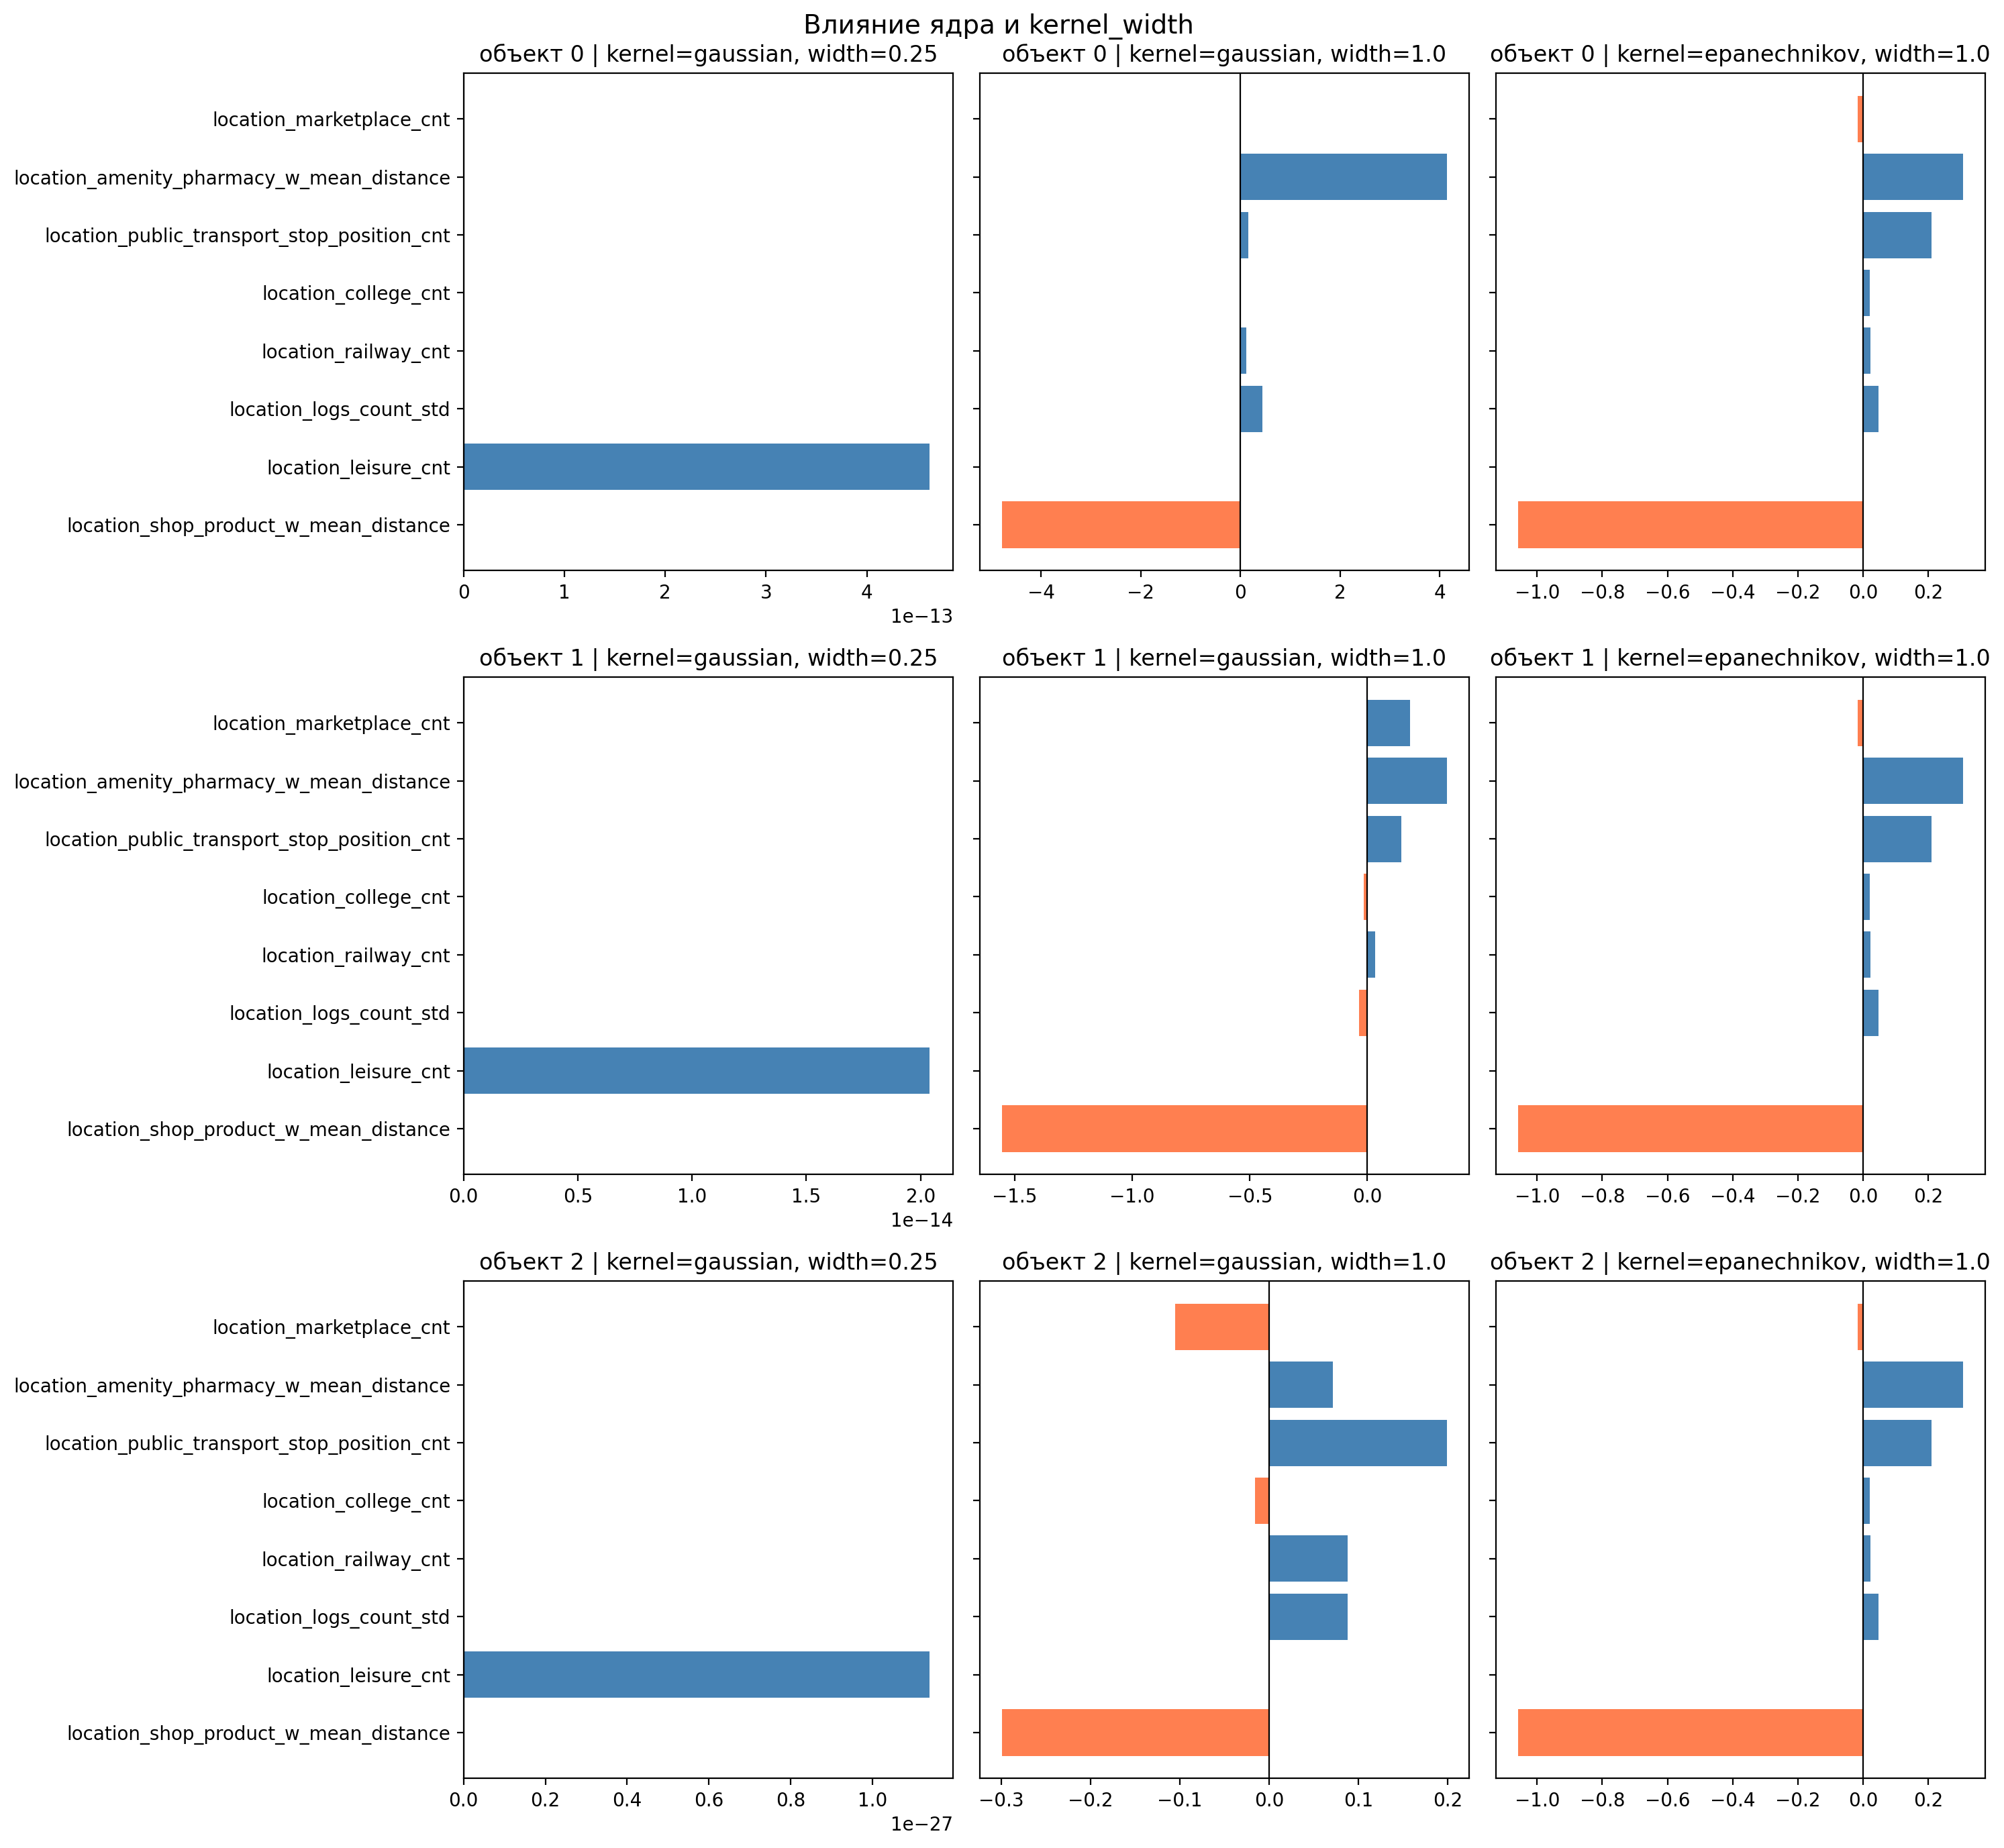

In [ ]:
# Применение MyLimeExplainer к задаче недвижимости

cat_modes = X_train[cat_features].mode().iloc[0]

def predict_num_only(X_array):
    X_df = pd.DataFrame(X_array, columns=num_features)
    for col in cat_features:
        X_df[col] = cat_modes[col]
    return gb_model.predict(X_df)

X_train_num = X_train[num_features].fillna(X_train[num_features].median()).values
X_test_num  = X_test[num_features].fillna(X_test[num_features].median()).values

my_explainer = MyLimeExplainer(
    training_data=X_train_num,
    feature_names=num_features,
    kernel_width=1.0,
    kernel="epanechnikov",
    random_state=42,
)

# 1. Интерпретация нескольких объектов
for idx in [0, 1, 2]:
    instance = X_test_num[idx]
    exp = my_explainer.explain_instance(
        instance, predict_num_only,
        num_features=8, n_samples=1000, feature_selection="lasso_path")
    pred = predict_num_only(instance.reshape(1, -1))[0]
    print(f"\n=== Объект {idx} | pred={pred:.1f} ===")
    for feat, coef in exp.items():
        print(f"  {feat:50s}: {coef:+.4f}")

# 2. Устойчивость: влияние num_samples
print("\n=== Влияние num_samples ===")
instance = X_test_num[0]
for n in [100, 500, 1000, 3000]:
    exp = my_explainer.explain_instance(
        instance, predict_num_only,
        num_features=5, n_samples=n, feature_selection="none")
    print(f"n_samples={n:5d}: { {k: round(v,4) for k,v in exp.items()} }")

# 3. Влияние feature_selection
print("\n=== lasso_path vs none ===")
for fs in ["lasso_path", "none"]:
    exp = my_explainer.explain_instance(
        instance, predict_num_only,
        num_features=5, n_samples=1000, feature_selection=fs)
    print(f"{fs}: { list(exp.items())[:3] }")

# 4. Влияние ядра и kernel_width
configs = [
    (0.25, "gaussian"),
    (1.0,  "gaussian"),
    (1.0,  "epanechnikov"),
]

fig, axes = plt.subplots(3, len(configs), figsize=(15, 14), sharey="row")

for row, idx in enumerate([0, 1, 2]):
    instance_i = X_test_num[idx]
    for col, (kw, kern) in enumerate(configs):
        exp = MyLimeExplainer(X_train_num, num_features,
                              kernel_width=kw, kernel=kern, random_state=42
                              ).explain_instance(instance_i, predict_num_only,
                                                 num_features=8, n_samples=1000,
                                                 feature_selection="none")
        names = list(exp.keys())
        coefs = list(exp.values())
        ax = axes[row, col]
        ax.barh(names, coefs,
                color=["steelblue" if c > 0 else "coral" for c in coefs])
        ax.axvline(0, color="black", linewidth=0.8)
        ax.set_title(f"объект {idx} | kernel={kern}, width={kw}")
        ax.invert_yaxis()

plt.suptitle("Влияние ядра и kernel_width", fontsize=14)
plt.tight_layout()
plt.show()


## Сравнение с библиотечным LIME

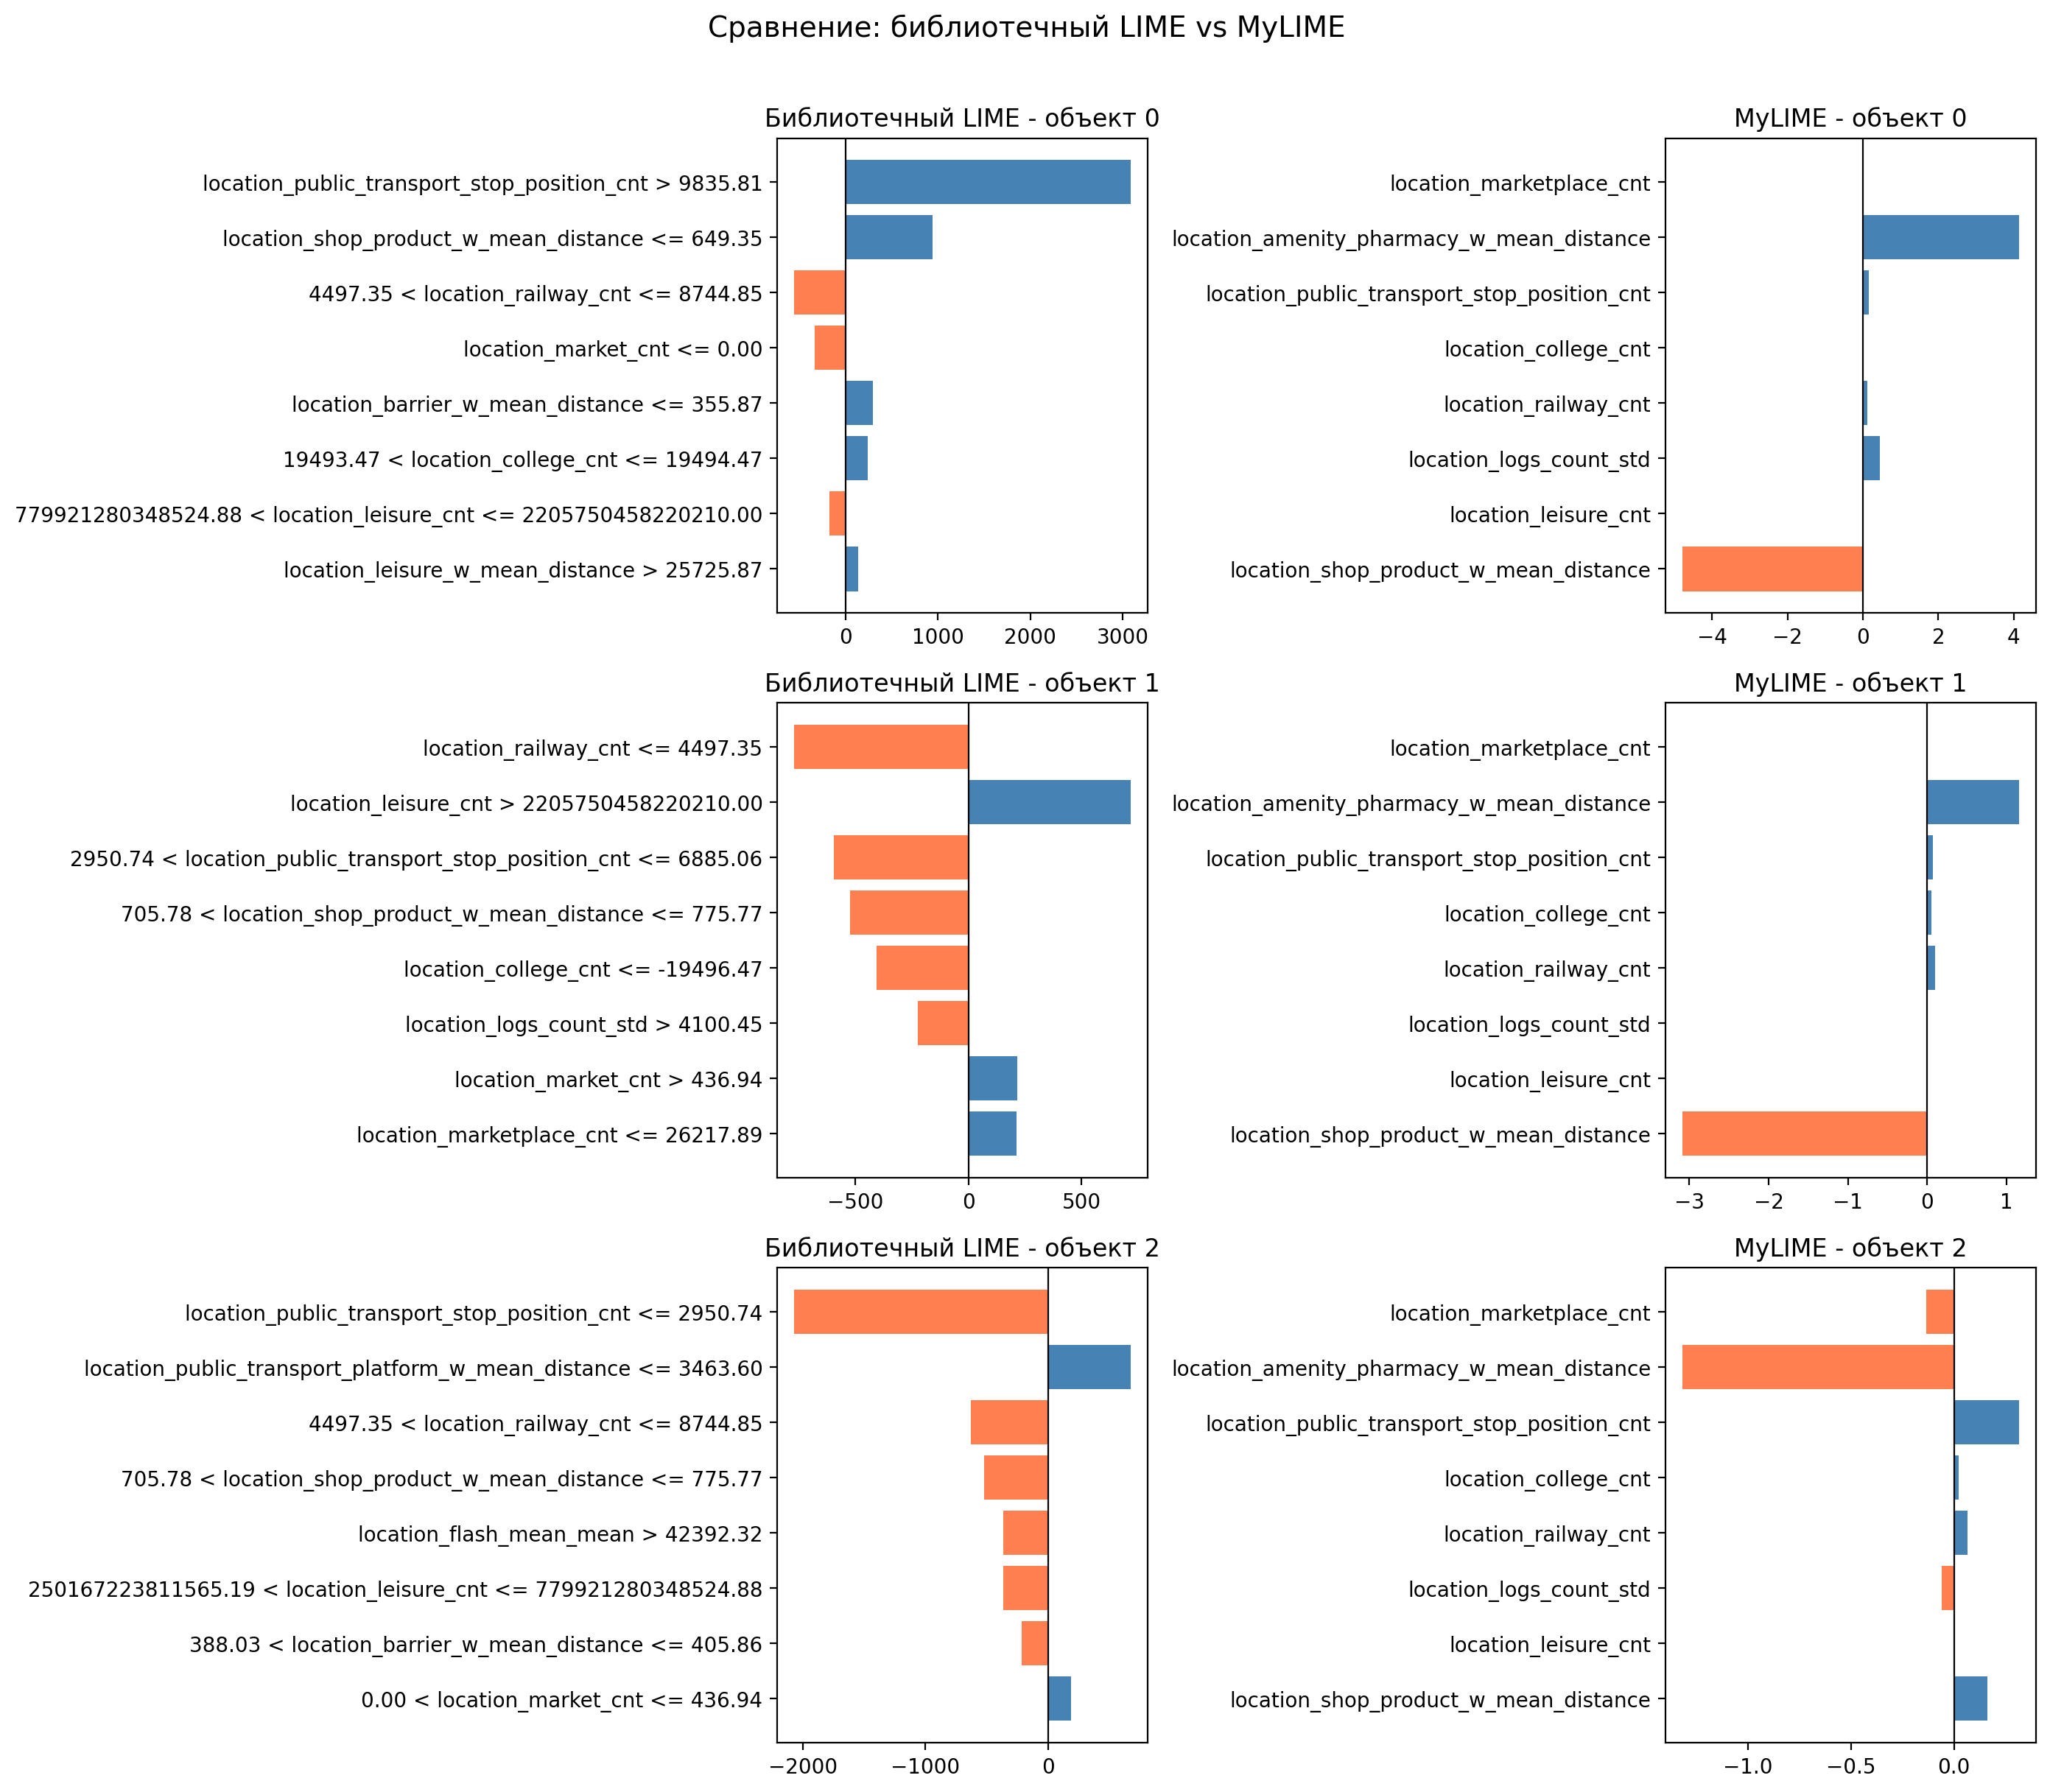

Объект                   Топ библиотечный                     Топ MyLIME
------------------------------------------------------------------------
  [0]    public_transport_stop_position_cnt > 9835.81 (+3190.004)                   shop_product (-1.507)
  [1]          railway_cnt <= 4497.35 (-655.229)               amenity_pharmacy (+2.870)
  [2]    public_transport_stop_position_cnt <= 2950.74 (-2246.426)               amenity_pharmacy (+1.894)


In [5]:
import lime
import lime.lime_tabular
import matplotlib.pyplot as plt
import numpy as np

# Настройка обоих explainer-ов
lib_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train_num,
    feature_names=num_features,
    mode="regression",
    discretize_continuous=True,
    random_state=42,
)

my_explainer_cmp = MyLimeExplainer(
    training_data=X_train_num,
    feature_names=num_features,
    kernel_width=1.0,
    kernel="gaussian",
    random_state=42,
)

N_SAMPLES = 1000
NUM_FEATURES = 8

# Сравнение на трёх объектах
fig, axes = plt.subplots(3, 2, figsize=(14, 12))

for row, idx in enumerate([0, 1, 2]):
    instance = X_test_num[idx]

    # Библиотечный LIME
    lib_exp = lib_explainer.explain_instance(
        instance, predict_num_only,
        num_features=NUM_FEATURES, num_samples=N_SAMPLES)
    lib_coefs = dict(lib_exp.as_list())

    # MyLIME
    my_exp = my_explainer_cmp.explain_instance(
        instance, predict_num_only,
        num_features=NUM_FEATURES, n_samples=N_SAMPLES,
        feature_selection="lasso_path")

    # ── Библиотечный ──
    ax_lib = axes[row, 0]
    names_l = list(lib_coefs.keys())
    coefs_l = list(lib_coefs.values())
    ax_lib.barh(names_l, coefs_l,
                color=["steelblue" if c > 0 else "coral" for c in coefs_l])
    ax_lib.axvline(0, color="black", linewidth=0.8)
    ax_lib.set_title(f"Библиотечный LIME - объект {idx}")
    ax_lib.invert_yaxis()

    # ── MyLime ──
    ax_my = axes[row, 1]
    names_m = list(my_exp.keys())
    coefs_m = list(my_exp.values())
    ax_my.barh(names_m, coefs_m,
               color=["steelblue" if c > 0 else "coral" for c in coefs_m])
    ax_my.axvline(0, color="black", linewidth=0.8)
    ax_my.set_title(f"MyLIME - объект {idx}")
    ax_my.invert_yaxis()

plt.suptitle("Сравнение: библиотечный LIME vs MyLIME", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# Численное сравнение: топ-признаки по модулю коэффициента
print(f"{'Объект':<10} {'Топ библиотечный':>30} {'Топ MyLIME':>30}")
print("-" * 72)
for idx in [0, 1, 2]:
    instance = X_test_num[idx]

    lib_exp = lib_explainer.explain_instance(
        instance, predict_num_only,
        num_features=NUM_FEATURES, num_samples=N_SAMPLES)
    lib_top = sorted(lib_exp.as_list(), key=lambda x: abs(x[1]), reverse=True)[0]

    my_exp = my_explainer_cmp.explain_instance(
        instance, predict_num_only,
        num_features=NUM_FEATURES, n_samples=N_SAMPLES,
        feature_selection="lasso_path")
    my_top = sorted(my_exp.items(), key=lambda x: abs(x[1]), reverse=True)[0]

    # Сокращаем длинные имена для читаемости
    def short(name): return name.replace("location_", "").replace("_w_mean_distance", "")

    print(f"  [{idx}]    {short(lib_top[0]):>28} ({lib_top[1]:+.3f})"
          f"   {short(my_top[0]):>28} ({my_top[1]:+.3f})")


### Сравнение библиотечного LIME и своего

**Масштаб коэффициентов:**
Библиотечный LIME выдаёт коэффициенты порядка ±500-3000, MyLIME - ±0.1-5.
Прямое сравнение величин бессмысленно: библиотека работает с бинаризованными
признаками (0/1 после дискретизации), наша реализация - с исходными числовыми
значениями. Сравнивать нужно только знаки и ранги.

**Что совпадает:**
- `location_shop_product_w_mean_distance` отрицательный у обоих методов во всех
  трёх объектах - самый устойчивый результат.
- `location_public_transport_stop_position_cnt` и `location_railway_cnt` совпадают
  по знаку в большинстве объектов.

**Ключевое отличие - дискретизация:**
Библиотека разбивает каждый признак на бины и объясняет через условия вида
`location_railway_cnt <= 4497.35`. Это даёт более информативное объяснение:
видно не просто признак важен, а важно что значение выше/ниже конкретного
порога. MyLIME работает с исходными значениями и даёт один коэффициент на
весь признак без привязки к порогу.

**Стабильность:**
Библиотечный LIME стабильнее при повторных запусках. В MyLIME такие признаки
как `location_amenity_pharmacy_w_mean_distance` меняют знак - следствие
глобального сэмплинга соседей из N(μ, σ) вместо локальной окрестности объекта.

**`location_leisure_cnt`:**
У библиотеки значимый для объекта 1 (большой положительный коэффициент),
у MyLIME - около нуля для всех объектов. Библиотека нашла конкретный бин
этого признака, важный локально - наша реализация эту локальную деталь потеряла.

**Итог:**
Оба метода сходятся на ключевых признаках и знаках влияния. Библиотечный LIME
точнее локально за счёт дискретизации. MyLIME проще устроен и лучше подходит
для понимания алгоритма, но менее устойчив численно.

### Анализ результатов 

**Интерпретация объектов:**
- Во всех трёх объектах доминирует `location_shop_product_w_mean_distance` с большим
  отрицательным коэффициентом (~-3 до -5): чем дальше до магазинов, тем ниже цена.
- `location_railway_cnt` стабильно положительный - близость к ж/д инфраструктуре
  повышает предсказание.
- `location_leisure_cnt` даёт коэффициент ≈ 0 у всех трёх объектов - признак
  не влияет на предсказание локально.

**Влияние num_samples:**
Коэффициенты нестабильны даже при n_samples=3000 - знак `location_amenity_pharmacy_w_mean_distance`
меняется от -3.6 до +4.1. Это говорит о том, что данный признак сильно коррелирует
с другими, и локальная линейная аппроксимация не может устойчиво выделить его
индивидуальный вклад. В отличие от библиотечного LIME, эта реализация генерирует
соседей из глобального N(μ, σ), а не из окрестности объекта - это усиливает
нестабильность.

**lasso_path vs none:**
Качественно похожи - топ-признаки те же, но коэффициенты отличаются по знаку
у `location_amenity_pharmacy_w_mean_distance`. Это следствие той же нестабильности
из-за корреляций.

**Влияние kernel_width и kernel:**
- `width=0.25` (gaussian): коэффициенты близки к нулю (~e-19 - e-20).
  Ядро настолько узкое, что почти все соседи получают нулевой вес: сработал fallback
  к равномерным весам : по сути невзвешенная регрессия на случайных точках.
- `width=1.0`: разумные коэффициенты, но с разными величинами -
  более широкое ядро сглаживает локальные эффекты.
- `epanechnikov, width=1.0`: коэффициенты заметно меньше по модулю, чем у gaussian
  с той же шириной - жёсткое обнуление дальних соседей даёт более консервативные оценки.